In [1]:
%pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 33.1 MB/s  0:00:000.7 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 26.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]━ 3/4 [geopandas]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import geopandas as gpd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)

In [3]:
data_dir = Path("data")

csv_files = sorted(data_dir.glob("CRMLSSold*.csv"))

print(f"Found {len(csv_files)} CSV files")
csv_files[-5:]

Found 31 CSV files


[PosixPath('data/CRMLSSold202602.csv'),
 PosixPath('data/CRMLSSold202603.csv'),
 PosixPath('data/CRMLSSold202604.csv'),
 PosixPath('data/CRMLSSold202605.csv'),
 PosixPath('data/CRMLSSold202606.csv')]

In [4]:
dfs = []

for file in csv_files:
    temp = pd.read_csv(file, low_memory=False)
    temp["source_file"] = file.name
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
df.head()

(818778, 83)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,source_file,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.0,Michelle,Fairchild,33.699517,-117.960655,231 Albatross Lane,ManufacturedInPark,1368.0,98000.0,86.0,Premiere Choice R E Inc,Premiere Choice R E Inc,Premiere Choice R E Inc,Michelle Fairchild,Josh,Lukasiewicz,ocfairmic,Michelle,Fairchild,NaN,NaN,NaN,556366533.0,16 - Fountain Valley / Northeast HB,NaN,Orange,Closed,NaN,NaN,2.0,NaN,NaN,NaN,Rancho la Siesta 55+ Senior,OrangeCounty,1969.0,Item,231.0,OC21227682,2.0,Fountain Valley,1500.00,NaN,NaN,2.0,2022-02-25,NaN,NaN,2022-01-28,2021-10-13,NaN,NaN,CA,NaN,NaN,NaN,1.0,NaN,One,NaN,NaN,NaN,NaN,0.0,ABC Unified,92708,0.0,NaN,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
1,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,2022-02-19,1200.0,DINESH,MAYANI,34.497691,-117.192323,21601 Powhatan Road 2,ResidentialLease,850.0,1200.0,125.0,California Real Estate & Investments,California Real Estate & Investments,NaN,DINESH MAYANI,NaN,NaN,evmayadin,DINESH,MAYANI,NaN,NaN,NaN,556366530.0,APPV - Apple Valley,NaN,San Bernardino,Closed,NaN,False,1.0,NaN,Apartment,0.9871,NaN,EastValley,1987.0,Item,21601.0,EV21227683,1.0,Apple Valley,100.00,NaN,NaN,2.0,2022-02-19,NaN,NaN,2022-02-19,2021-10-13,NaN,NaN,CA,NaN,NaN,False,1.0,NaN,One,NaN,43000.0,2.0,False,1.0,Apple Valley Unified,92308,0.0,43000.0,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
2,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.0,Cindy,Davis,32.981292,-117.262529,827 Del Mar Downs Rd. D,Residential,1344.0,1100000.0,106.0,SD Home Source Realty,Compass,NaN,Cindy Davis,NaN,NaN,SAND-646850,Lindsay,Dunlap,NaN,Monthly,NaN,556366044.0,92075 - Solana Beach,NaN,San Diego,Closed,NaN,True,2.0,NaN,Townhouse,NaN,NaN,SanDiego,1974.0,Item1,827.0,NDP2111697,3.0,Solana Beach,1.50,NaN,NaN,3.0,2022-04-15,NaN,NaN,2022-02-03,2021-10-13,NaN,NaN,CA,NaN,NaN,True,2.0,NaN,Two,NaN,NaN,0.0,NaN,1.0,Solana Beach,92075,370.0,NaN,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,Bryan,Meathe,33.147270,-117.340604,295 Chinquapin Ave,Residential,2645.0,2499999.0,37.0,Coldwell Banker Realty,ERA Ranch & Sea Realty,NaN,Bryan Meathe,NaN,NaN,101046,Bill,Kellaway,NaN,Monthly,NaN,556365765.0,92008 - Carlsbad,NaN,San Diego,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,0.3071,NaN,NorthSanDiegoCounty,2016.0,Item1,295.0,NDP2111696,4.0,Carlsbad,2.25,NaN,NaN,4.0,2022-01-04,NaN,NaN,2021-11-19,2021-10-13,NaN,NaN,CA,NaN,NaN,False,NaN,NaN,ThreeOrMore,NaN,13376.0,0.0,NaN,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,CRMLSSold20220101_20231231_filled.cs

In [5]:
df.columns = df.columns.str.strip()

df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
].copy()

df.shape

(412015, 83)

In [6]:
df = df.rename(columns={
    "BedroomsTotal": "Bedrooms",
    "BathroomsTotalInteger": "Bathrooms",
    "LotSizeSquareFeet": "LotSize"
})

In [7]:
needed_cols = [
    "CloseDate",
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "Latitude",
    "Longitude",
    "YearBuilt"
]

for col in needed_cols:
    print(col, col in df.columns)

CloseDate True
ClosePrice True
LivingArea True
Bedrooms True
Bathrooms True
LotSize True
Latitude True
Longitude True
YearBuilt True


In [8]:
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
df["CloseMonth"] = df["CloseDate"].dt.to_period("M")

df = df.dropna(subset=["CloseDate", "ClosePrice"]).copy()
df = df.sort_values("CloseDate").reset_index(drop=True)

print("Date range:", df["CloseDate"].min(), "to", df["CloseDate"].max())
df["CloseMonth"].value_counts().sort_index()

Date range: 2022-01-01 00:00:00 to 2026-06-30 00:00:00


CloseMonth
2022-01     2313
2022-02     1227
2022-03      873
2022-04      408
2022-05      229
2022-06      171
2022-07      100
2022-08       72
2022-09       50
2022-10       38
2022-11       23
2022-12       17
2023-01       12
2023-02       19
2023-03       20
2023-04       80
2023-05     1832
2023-06     8601
2023-07     9888
2023-08    11715
2023-09    10744
2023-10    11033
2023-11     9668
2023-12     9518
2024-01     8322
2024-02     9564
2024-03    11634
2024-04    12745
2024-05    13831
2024-06    12544
2024-07    13378
2024-08    12433
2024-09    10909
2024-10    12347
2024-11    10692
2024-12    10623
2025-01     8144
2025-02     8851
2025-03    10610
2025-04    11880
2025-05    11777
2025-06    11701
2025-07    12114
2025-08    11454
2025-09    11456
2025-10    12029
2025-11     9739
2025-12    10455
2026-01     7490
2026-02     8550
2026-03    11177
2026-04    12031
2026-05    12024
2026-06    12858
Freq: M, Name: count, dtype: int64

In [9]:
all_months = sorted(df["CloseMonth"].dropna().unique())

test_month = all_months[-1]

train_df_check = df[df["CloseMonth"] < test_month]
test_df_check = df[df["CloseMonth"] == test_month]

print("Test month:", test_month)
print("Train date range:", train_df_check["CloseDate"].min(), "to", train_df_check["CloseDate"].max())
print("Test date range:", test_df_check["CloseDate"].min(), "to", test_df_check["CloseDate"].max())
print("Train rows:", len(train_df_check))
print("Test rows:", len(test_df_check))

Test month: 2026-06
Train date range: 2022-01-01 00:00:00 to 2026-05-31 00:00:00
Test date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00
Train rows: 399155
Test rows: 12858


In [10]:
model_df = df.copy()

numeric_cols = ["ClosePrice", "LivingArea", "Bedrooms", "Bathrooms", "LotSize", "Latitude", "Longitude"]

if "YearBuilt" in model_df.columns:
    numeric_cols.append("YearBuilt")

for col in numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

In [11]:
# Missing flags for original numeric features
base_numeric_features = ["LivingArea", "Bedrooms", "Bathrooms", "LotSize"]

for col in base_numeric_features:
    model_df[f"{col}_missing"] = model_df[col].isna().astype(int)

In [12]:
# Engineered features

model_df["BedBathRatio"] = model_df["Bedrooms"] / model_df["Bathrooms"].replace(0, np.nan)

model_df["TotalRoomsProxy"] = model_df["Bedrooms"] + model_df["Bathrooms"]

model_df["log_LivingArea"] = np.log1p(model_df["LivingArea"])
model_df["log_LotSize"] = np.log1p(model_df["LotSize"])

if "YearBuilt" in model_df.columns:
    model_df["PropertyAge"] = model_df["CloseDate"].dt.year - model_df["YearBuilt"]
    model_df.loc[
        (model_df["PropertyAge"] < 0) | (model_df["PropertyAge"] > 300),
        "PropertyAge"
    ] = np.nan

In [14]:
from pathlib import Path
import geopandas as gpd

geo_path = Path("geo/ca_school_districts.geojson")

print("File exists?", geo_path.exists())
print("Path:", geo_path)

File exists? True
Path: geo/ca_school_districts.geojson


In [15]:
districts = gpd.read_file(geo_path)

print(districts.shape)
districts.head()

(936, 51)


,OBJECTID,Year,FedID,CDCode,CDSCode,CountyName,DistrictName,DistrictType,GradeLow,GradeHigh,GradeLowCensus,GradeHighCensus,AssistStatus,UpdateNotes,EnrollTotal,EnrollCharter,EnrollNonCharter,AAcount,AApct,AIcount,AIpct,AScount,ASpct,FIcount,FIpct,HIcount,HIpct,PIcount,PIpct,WHcount,WHpct,MRcount,MRpct,NRcount,NRpct,ELcount,ELpct,FOScount,FOSpct,HOMcount,HOMpct,MIGcount,MIGpct,SWDcount,SWDpct,SEDcount,SEDpct,DistrctAreaSqMi,LocaleCode,LocaleDesc,geometry
0,1,2025-26,0601770,0161119,01611190000000,Alameda,Alameda Unified,Unified,PK,12,KG,12,"Differentiated, Year 1",SY 2018-19 Boundary Adjustment/Correction,10781,1420,9361,773,7.2,24,0.2,2610,24.2,477,4.4,1930,17.9,52,0.5,2837,26.3,1739,16.1,339,3.1,904,8.4,22,0.2,80,0.7,0,0.0,1302,12.1,4259,39.5,11.248886,21,"21 - Suburban, Large","MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,2,2025-26,0601860,0161127,01611270000000,Alameda,Albany City Unified,Unified,PK,12,KG,12,General,None,3749,0,3749,138,3.7,9,0.2,1143,30.5,55,1.5,646,17.2,3,0.1,855,22.8,490,13.1,410,10.9,400,10.7,0,0.0,20,0.5,0,0.0,363,9.7,1247,33.3,1.789975,21,"21 - Suburban, Large","POLYGON ((-13612893.866 4565099.707, -13612896..."
2,3,2025-26,0604740,0161143,01611430000000,Alameda,Berkeley Unified,Unified,PK,12,KG,12,"Differentiated, Year 2",None,9398,0,9398,1063,11.3,19,0.2,789,8.4,78,0.8,2051,21.8,19,0.2,3800,40.4,1571,16.7,8,0.1,505,5.4,24,0.3,202,2.1,0,0.0,1118,11.9,2710,28.8,10.434281,12,"12 - City, Midsize","POLYGON ((-13609482.48 4565074.597, -13609483...."
3,4,2025-26,0607800,0161150,01611500000000,Alameda,Castro Valley Unified,Unified,PK,12,KG,12,"Differentiated, Year 1",SY 2018-19 Boundary Adjustment/Correction,9713,0,9713,385,4.0,13,0.1,3435,35.4,411,4.2,2355,24.2,36,0.4,1707,17.6,1013,10.4,358,3.7,1166,12.0,7,0.1,84,0.9,2,0.0,1186,12.2,3784,39.0,66.885261,21,"21 - Suburban, Large","MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,5,2025-26,0612630,0161168,01611680000000,Alameda,Emery Unified,Unified,PK,12,KG,12,"Differentiated, Year 1",None,610,0,610,250,41.0,1,0.2,67,11.0,5,0.8,141,23.1,3,0.5,69,11.3,54,8.9,20,3.3,106,17.4,2,0.3,6,1.0,0,0.0,98,16.1,407,66.7,1.273923,21,"21 - Suburban, Large","POLYGON ((-13613999.038 4555592.769, -13614126..."


In [16]:
districts.columns.tolist()

['OBJECTID',
 'Year',
 'FedID',
 'CDCode',
 'CDSCode',
 'CountyName',
 'DistrictName',
 'DistrictType',
 'GradeLow',
 'GradeHigh',
 'GradeLowCensus',
 'GradeHighCensus',
 'AssistStatus',
 'UpdateNotes',
 'EnrollTotal',
 'EnrollCharter',
 'EnrollNonCharter',
 'AAcount',
 'AApct',
 'AIcount',
 'AIpct',
 'AScount',
 'ASpct',
 'FIcount',
 'FIpct',
 'HIcount',
 'HIpct',
 'PIcount',
 'PIpct',
 'WHcount',
 'WHpct',
 'MRcount',
 'MRpct',
 'NRcount',
 'NRpct',
 'ELcount',
 'ELpct',
 'FOScount',
 'FOSpct',
 'HOMcount',
 'HOMpct',
 'MIGcount',
 'MIGpct',
 'SWDcount',
 'SWDpct',
 'SEDcount',
 'SEDpct',
 'DistrctAreaSqMi',
 'LocaleCode',
 'LocaleDesc',
 'geometry']

In [17]:
unified_districts = districts[
    districts["DistrictType"].astype(str).str.lower() == "unified"
].copy()

print(unified_districts.shape)
unified_districts[["DistrictName", "DistrictType"]].head()

(345, 51)


,DistrictName,DistrictType
0,Alameda Unified,Unified
1,Albany City Unified,Unified
2,Berkeley Unified,Unified
3,Castro Valley Unified,Unified
4,Emery Unified,Unified


In [18]:
model_df = model_df.reset_index(drop=True)
model_df["row_id"] = model_df.index

properties_with_coords = model_df.dropna(subset=["Latitude", "Longitude"]).copy()

properties_gdf = gpd.GeoDataFrame(
    properties_with_coords,
    geometry=gpd.points_from_xy(
        properties_with_coords["Longitude"],
        properties_with_coords["Latitude"]
    ),
    crs="EPSG:4326"
)

properties_gdf.shape

(411820, 95)

In [19]:
if unified_districts.crs != properties_gdf.crs:
    unified_districts = unified_districts.to_crs(properties_gdf.crs)

print("Properties CRS:", properties_gdf.crs)
print("Districts CRS:", unified_districts.crs)

Properties CRS: EPSG:4326
Districts CRS: EPSG:4326


In [20]:
district_cols = ["DistrictName", "DistrictType", "geometry"]

joined = gpd.sjoin(
    properties_gdf,
    unified_districts[district_cols],
    how="left",
    predicate="within"
)

joined[["row_id", "DistrictName", "DistrictType"]].head()

,row_id,DistrictName,DistrictType
0,0,Morongo Unified,Unified
1,1,Morongo Unified,Unified
2,2,Los Angeles Unified,Unified
3,3,Hemet Unified,Unified
4,4,San Jacinto Unified,Unified


In [21]:
district_lookup = (
    joined[["row_id", "DistrictName"]]
    .drop_duplicates(subset=["row_id"])
)

model_df = model_df.merge(
    district_lookup,
    on="row_id",
    how="left"
)

model_df["DistrictName"] = model_df["DistrictName"].fillna("Unknown")

model_df["DistrictName"].value_counts(dropna=False).head(20)

DistrictName
Unknown                        103743
Los Angeles Unified             39728
San Diego Unified               10917
Capistrano Unified               7355
Desert Sands Unified             7244
Palm Springs Unified             6213
Oakland Unified                  5340
Corona-Norco Unified             5189
Hemet Unified                    5027
Long Beach Unified               4865
Riverside Unified                4723
Temecula Valley Unified          4572
Mt. Diablo Unified               4300
San Bernardino City Unified      3831
Lake Elsinore Unified            3587
Saddleback Valley Unified        3456
Poway Unified                    3395
Orange Unified                   3169
Newport-Mesa Unified             3138
Hesperia Unified                 3136
Name: count, dtype: int64

In [22]:
model_df.to_csv("residential_single_family_enriched_week6.csv", index=False)

In [23]:
print("Total rows:", len(model_df))
print("Rows with DistrictName:", model_df["DistrictName"].notna().sum())
print("Rows with Unknown district:", (model_df["DistrictName"] == "Unknown").sum())

unknown_pct = (model_df["DistrictName"] == "Unknown").mean() * 100
print(f"Unknown district percentage: {unknown_pct:.2f}%")

model_df["DistrictName"].value_counts(dropna=False).head(20)

Total rows: 412013
Rows with DistrictName: 412013
Rows with Unknown district: 103743
Unknown district percentage: 25.18%


DistrictName
Unknown                        103743
Los Angeles Unified             39728
San Diego Unified               10917
Capistrano Unified               7355
Desert Sands Unified             7244
Palm Springs Unified             6213
Oakland Unified                  5340
Corona-Norco Unified             5189
Hemet Unified                    5027
Long Beach Unified               4865
Riverside Unified                4723
Temecula Valley Unified          4572
Mt. Diablo Unified               4300
San Bernardino City Unified      3831
Lake Elsinore Unified            3587
Saddleback Valley Unified        3456
Poway Unified                    3395
Orange Unified                   3169
Newport-Mesa Unified             3138
Hesperia Unified                 3136
Name: count, dtype: int64

In [24]:
model_df["HasUnifiedDistrict"] = (model_df["DistrictName"] != "Unknown").astype(int)

model_df[["DistrictName", "HasUnifiedDistrict"]].head()

,DistrictName,HasUnifiedDistrict
0,Morongo Unified,1
1,Morongo Unified,1
2,Los Angeles Unified,1
3,Hemet Unified,1
4,San Jacinto Unified,1


In [25]:
numeric_to_clean = [
    "ClosePrice",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "Latitude",
    "Longitude"
]

if "YearBuilt" in model_df.columns:
    numeric_to_clean.append("YearBuilt")

for col in numeric_to_clean:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

In [26]:
base_numeric_features = [
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize"
]

for col in base_numeric_features:
    model_df[f"{col}_missing"] = model_df[col].isna().astype(int)

model_df["BedBathRatio"] = model_df["Bedrooms"] / model_df["Bathrooms"].replace(0, np.nan)

model_df["TotalRoomsProxy"] = model_df["Bedrooms"] + model_df["Bathrooms"]

model_df["log_LivingArea"] = np.log1p(model_df["LivingArea"])

model_df["log_LotSize"] = np.log1p(model_df["LotSize"])

if "YearBuilt" in model_df.columns:
    model_df["PropertyAge"] = model_df["CloseDate"].dt.year - model_df["YearBuilt"]
    
    model_df.loc[
        (model_df["PropertyAge"] < 0) | (model_df["PropertyAge"] > 300),
        "PropertyAge"
    ] = np.nan

In [27]:
model_df.to_csv("residential_single_family_geocoding_week6.csv", index=False)

In [28]:
model_df["CloseDate"] = pd.to_datetime(model_df["CloseDate"], errors="coerce")
model_df["CloseMonth"] = model_df["CloseDate"].dt.to_period("M")

model_df = model_df.dropna(subset=["CloseDate", "ClosePrice"]).copy()
model_df = model_df.sort_values("CloseDate").reset_index(drop=True)

all_months = sorted(model_df["CloseMonth"].dropna().unique())
test_month = all_months[-1]

train_df = model_df[model_df["CloseMonth"] < test_month].copy()
test_df = model_df[model_df["CloseMonth"] == test_month].copy()

print("Test month:", test_month)
print("Train date range:", train_df["CloseDate"].min(), "to", train_df["CloseDate"].max())
print("Test date range:", test_df["CloseDate"].min(), "to", test_df["CloseDate"].max())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Test month: 2026-06
Train date range: 2022-01-01 00:00:00 to 2026-05-31 00:00:00
Test date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00
Train rows: 399155
Test rows: 12858


In [29]:
target = "ClosePrice"

old_numeric_features = [
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "LivingArea_missing",
    "Bedrooms_missing",
    "Bathrooms_missing",
    "LotSize_missing"
]

new_numeric_features = old_numeric_features + [
    "BedBathRatio",
    "TotalRoomsProxy",
    "log_LivingArea",
    "log_LotSize",
    "HasUnifiedDistrict"
]

if "PropertyAge" in model_df.columns:
    new_numeric_features.append("PropertyAge")

new_categorical_features = [
    "DistrictName"
]

print("Old numeric features:")
print(old_numeric_features)

print("\nNew numeric features:")
print(new_numeric_features)

print("\nNew categorical features:")
print(new_categorical_features)

Old numeric features:
['LivingArea', 'Bedrooms', 'Bathrooms', 'LotSize', 'LivingArea_missing', 'Bedrooms_missing', 'Bathrooms_missing', 'LotSize_missing']

New numeric features:
['LivingArea', 'Bedrooms', 'Bathrooms', 'LotSize', 'LivingArea_missing', 'Bedrooms_missing', 'Bathrooms_missing', 'LotSize_missing', 'BedBathRatio', 'TotalRoomsProxy', 'log_LivingArea', 'log_LotSize', 'HasUnifiedDistrict', 'PropertyAge']

New categorical features:
['DistrictName']


### School District Mapping Quality

The spatial join assigned a unified school district to about 75% of properties. Around 25% of rows were labeled as `Unknown`. Since the school district boundary dataset was filtered to `DistrictType = Unified`, these unknown values may represent properties located in areas served by separate elementary and high school districts rather than unified districts.

I kept `Unknown` as its own category rather than dropping those rows. I also added a `HasUnifiedDistrict` indicator so the model can learn whether a property successfully matched to a unified district.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

print("Train date range:", train_df["CloseDate"].min(), "to", train_df["CloseDate"].max())
print("Test date range:", test_df["CloseDate"].min(), "to", test_df["CloseDate"].max())

print("Train months:", sorted(train_df["CloseMonth"].unique())[-5:])
print("Test month:", sorted(test_df["CloseMonth"].unique()))

Train rows: 399155
Test rows: 12858
Train date range: 2022-01-01 00:00:00 to 2026-05-31 00:00:00
Test date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00
Train months: [Period('2026-01', 'M'), Period('2026-02', 'M'), Period('2026-03', 'M'), Period('2026-04', 'M'), Period('2026-05', 'M')]
Test month: [Period('2026-06', 'M')]


In [32]:
target = "ClosePrice"

old_numeric_features = [
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "LivingArea_missing",
    "Bedrooms_missing",
    "Bathrooms_missing",
    "LotSize_missing"
]

new_numeric_features = old_numeric_features + [
    "BedBathRatio",
    "TotalRoomsProxy",
    "log_LivingArea",
    "log_LotSize",
    "HasUnifiedDistrict"
]

if "PropertyAge" in model_df.columns:
    new_numeric_features.append("PropertyAge")

new_categorical_features = [
    "DistrictName"
]

print("Old numeric features:")
print(old_numeric_features)

print("\nNew numeric features:")
print(new_numeric_features)

print("\nNew categorical features:")
print(new_categorical_features)

Old numeric features:
['LivingArea', 'Bedrooms', 'Bathrooms', 'LotSize', 'LivingArea_missing', 'Bedrooms_missing', 'Bathrooms_missing', 'LotSize_missing']

New numeric features:
['LivingArea', 'Bedrooms', 'Bathrooms', 'LotSize', 'LivingArea_missing', 'Bedrooms_missing', 'Bathrooms_missing', 'LotSize_missing', 'BedBathRatio', 'TotalRoomsProxy', 'log_LivingArea', 'log_LotSize', 'HasUnifiedDistrict', 'PropertyAge']

New categorical features:
['DistrictName']


In [33]:
required_old_cols = old_numeric_features + [target]
required_new_cols = new_numeric_features + new_categorical_features + [target]

missing_old = [col for col in required_old_cols if col not in model_df.columns]
missing_new = [col for col in required_new_cols if col not in model_df.columns]

print("Missing old feature columns:", missing_old)
print("Missing new feature columns:", missing_new)

Missing old feature columns: []
Missing new feature columns: []


In [34]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    mask = y_true != 0
    y_true_nonzero = y_true[mask]
    y_pred_nonzero = y_pred[mask]
    
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true_nonzero, y_pred_nonzero)
    mdape = np.median(
        np.abs((y_true_nonzero - y_pred_nonzero) / y_true_nonzero)
    )
    
    return {
        "R2": r2,
        "MAPE": mape,
        "MdAPE": mdape
    }

In [35]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])
    
    transformers = [
        ("num", numeric_transformer, numeric_features)
    ]
    
    if len(categorical_features) > 0:
        transformers.append(("cat", categorical_transformer, categorical_features))
    
    preprocessor = ColumnTransformer(transformers=transformers)
    
    return preprocessor

In [36]:
def evaluate_model_set(feature_set_name, numeric_features, categorical_features):
    all_features = numeric_features + categorical_features
    
    X_train = train_df[all_features]
    y_train = train_df[target]
    
    X_test = test_df[all_features]
    y_test = test_df[target]
    
    preprocessor = build_preprocessor(numeric_features, categorical_features)
    
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(
            max_depth=8,
            min_samples_leaf=20,
            random_state=42
        ),
        "Random Forest": RandomForestRegressor(
            n_estimators=100,
            max_depth=18,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
    }
    
    rows = []
    predictions = {}
    fitted_models = {}
    
    for model_name, estimator in models.items():
        pipe = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ])
        
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        
        metrics = regression_metrics(y_test, preds)
        
        rows.append({
            "Feature Set": feature_set_name,
            "Model": model_name,
            "R2": metrics["R2"],
            "MAPE": metrics["MAPE"],
            "MdAPE": metrics["MdAPE"]
        })
        
        predictions[(feature_set_name, model_name)] = preds
        fitted_models[(feature_set_name, model_name)] = pipe
    
    return rows, predictions, fitted_models

In [37]:
all_results = []
all_predictions = {}
all_fitted_models = {}

old_rows, old_predictions, old_fitted_models = evaluate_model_set(
    feature_set_name="Old Features",
    numeric_features=old_numeric_features,
    categorical_features=[]
)

new_rows, new_predictions, new_fitted_models = evaluate_model_set(
    feature_set_name="New Features + School District",
    numeric_features=new_numeric_features,
    categorical_features=new_categorical_features
)

all_results.extend(old_rows)
all_results.extend(new_rows)

all_predictions.update(old_predictions)
all_predictions.update(new_predictions)

all_fitted_models.update(old_fitted_models)
all_fitted_models.update(new_fitted_models)

comparison_results = pd.DataFrame(all_results)

comparison_results["MAPE_%"] = comparison_results["MAPE"] * 100
comparison_results["MdAPE_%"] = comparison_results["MdAPE"] * 100

comparison_results

,Feature Set,Model,R2,MAPE,MdAPE,MAPE_%,MdAPE_%
0,Old Features,Linear Regression,0.292492,0.782359,0.451772,78.235859,45.177248
1,Old Features,Decision Tree,0.264594,0.756144,0.370608,75.614412,37.060808
2,Old Features,Random Forest,0.138849,0.688787,0.334541,68.878718,33.454053
3,New Features + School District,Linear Regression,0.505912,0.529903,0.293466,52.990336,29.346557
4,New Features + School District,Decision Tree,0.343564,0.663734,0.320941,66.373355,32.094089
5,New Features + School District,Random Forest,0.356843,2.371295,0.249375,237.129456,24.937464


In [52]:
# comparison table for reporting

comparison_display = comparison_results.copy()

comparison_display["R2"] = comparison_display["R2"].round(4)
comparison_display["MAPE_%"] = comparison_display["MAPE_%"].round(2)
comparison_display["MdAPE_%"] = comparison_display["MdAPE_%"].round(2)

comparison_display = comparison_display[
    ["Feature Set", "Model", "R2", "MAPE_%", "MdAPE_%"]
]

comparison_display.sort_values(["Feature Set", "Model"])

,Feature Set,Model,R2,MAPE_%,MdAPE_%
4,New Features + School District,Decision Tree,0.3436,66.37,32.09
3,New Features + School District,Linear Regression,0.5059,52.99,29.35
5,New Features + School District,Random Forest,0.3568,237.13,24.94
1,Old Features,Decision Tree,0.2646,75.61,37.06
0,Old Features,Linear Regression,0.2925,78.24,45.18
2,Old Features,Random Forest,0.1388,68.88,33.45


In [38]:
comparison_results.sort_values("R2", ascending=False)

,Feature Set,Model,R2,MAPE,MdAPE,MAPE_%,MdAPE_%
3,New Features + School District,Linear Regression,0.505912,0.529903,0.293466,52.990336,29.346557
5,New Features + School District,Random Forest,0.356843,2.371295,0.249375,237.129456,24.937464
4,New Features + School District,Decision Tree,0.343564,0.663734,0.320941,66.373355,32.094089
0,Old Features,Linear Regression,0.292492,0.782359,0.451772,78.235859,45.177248
1,Old Features,Decision Tree,0.264594,0.756144,0.370608,75.614412,37.060808
2,Old Features,Random Forest,0.138849,0.688787,0.334541,68.878718,33.454053


In [39]:
comparison_results.sort_values("MdAPE", ascending=True)

,Feature Set,Model,R2,MAPE,MdAPE,MAPE_%,MdAPE_%
5,New Features + School District,Random Forest,0.356843,2.371295,0.249375,237.129456,24.937464
3,New Features + School District,Linear Regression,0.505912,0.529903,0.293466,52.990336,29.346557
4,New Features + School District,Decision Tree,0.343564,0.663734,0.320941,66.373355,32.094089
2,Old Features,Random Forest,0.138849,0.688787,0.334541,68.878718,33.454053
1,Old Features,Decision Tree,0.264594,0.756144,0.370608,75.614412,37.060808
0,Old Features,Linear Regression,0.292492,0.782359,0.451772,78.235859,45.177248


In [40]:
comparison_results.to_csv("week6_old_vs_new_feature_comparison.csv", index=False)

In [41]:
old_results = comparison_results[
    comparison_results["Feature Set"] == "Old Features"
].set_index("Model")

new_results = comparison_results[
    comparison_results["Feature Set"] == "New Features + School District"
].set_index("Model")

improvement_results = pd.DataFrame({
    "Old_R2": old_results["R2"],
    "New_R2": new_results["R2"],
    "R2_Change": new_results["R2"] - old_results["R2"],
    "Old_MAPE_%": old_results["MAPE_%"],
    "New_MAPE_%": new_results["MAPE_%"],
    "MAPE_%_Change": new_results["MAPE_%"] - old_results["MAPE_%"],
    "Old_MdAPE_%": old_results["MdAPE_%"],
    "New_MdAPE_%": new_results["MdAPE_%"],
    "MdAPE_%_Change": new_results["MdAPE_%"] - old_results["MdAPE_%"]
}).reset_index()

improvement_results

,Model,Old_R2,New_R2,R2_Change,Old_MAPE_%,New_MAPE_%,MAPE_%_Change,Old_MdAPE_%,New_MdAPE_%,MdAPE_%_Change
0,Linear Regression,0.292492,0.505912,0.213421,78.235859,52.990336,-25.245523,45.177248,29.346557,-15.830691
1,Decision Tree,0.264594,0.343564,0.078970,75.614412,66.373355,-9.241056,37.060808,32.094089,-4.966719
2,Random Forest,0.138849,0.356843,0.217994,68.878718,237.129456,168.250738,33.454053,24.937464,-8.516588


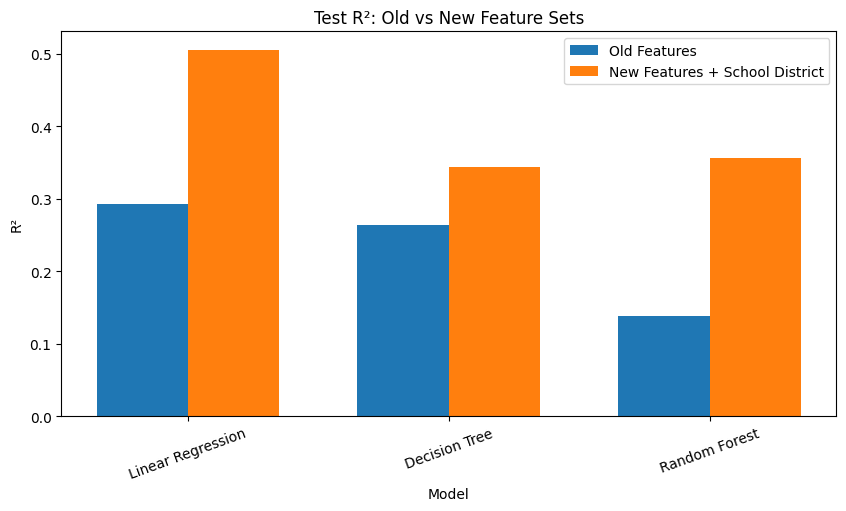

In [42]:
plt.figure(figsize=(10, 5))

models = comparison_results["Model"].unique()
x = np.arange(len(models))
width = 0.35

old_r2 = [
    comparison_results[
        (comparison_results["Feature Set"] == "Old Features") &
        (comparison_results["Model"] == model)
    ]["R2"].values[0]
    for model in models
]

new_r2 = [
    comparison_results[
        (comparison_results["Feature Set"] == "New Features + School District") &
        (comparison_results["Model"] == model)
    ]["R2"].values[0]
    for model in models
]

plt.bar(x - width / 2, old_r2, width, label="Old Features")
plt.bar(x + width / 2, new_r2, width, label="New Features + School District")

plt.title("Test R²: Old vs New Feature Sets")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(x, models, rotation=20)
plt.legend()
plt.show()

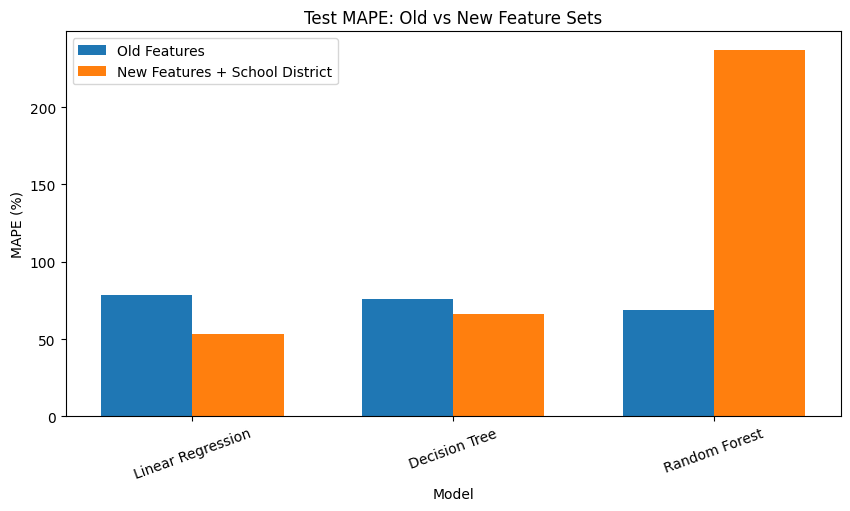

In [43]:
plt.figure(figsize=(10, 5))

old_mape = [
    comparison_results[
        (comparison_results["Feature Set"] == "Old Features") &
        (comparison_results["Model"] == model)
    ]["MAPE_%"].values[0]
    for model in models
]

new_mape = [
    comparison_results[
        (comparison_results["Feature Set"] == "New Features + School District") &
        (comparison_results["Model"] == model)
    ]["MAPE_%"].values[0]
    for model in models
]

plt.bar(x - width / 2, old_mape, width, label="Old Features")
plt.bar(x + width / 2, new_mape, width, label="New Features + School District")

plt.title("Test MAPE: Old vs New Feature Sets")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.xticks(x, models, rotation=20)
plt.legend()
plt.show()

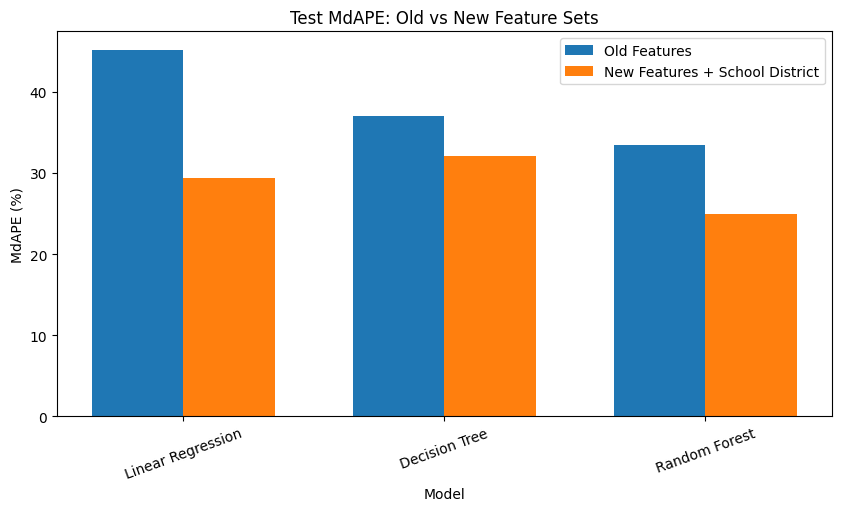

In [44]:
plt.figure(figsize=(10, 5))

old_mdape = [
    comparison_results[
        (comparison_results["Feature Set"] == "Old Features") &
        (comparison_results["Model"] == model)
    ]["MdAPE_%"].values[0]
    for model in models
]

new_mdape = [
    comparison_results[
        (comparison_results["Feature Set"] == "New Features + School District") &
        (comparison_results["Model"] == model)
    ]["MdAPE_%"].values[0]
    for model in models
]

plt.bar(x - width / 2, old_mdape, width, label="Old Features")
plt.bar(x + width / 2, new_mdape, width, label="New Features + School District")

plt.title("Test MdAPE: Old vs New Feature Sets")
plt.xlabel("Model")
plt.ylabel("MdAPE (%)")
plt.xticks(x, models, rotation=20)
plt.legend()
plt.show()

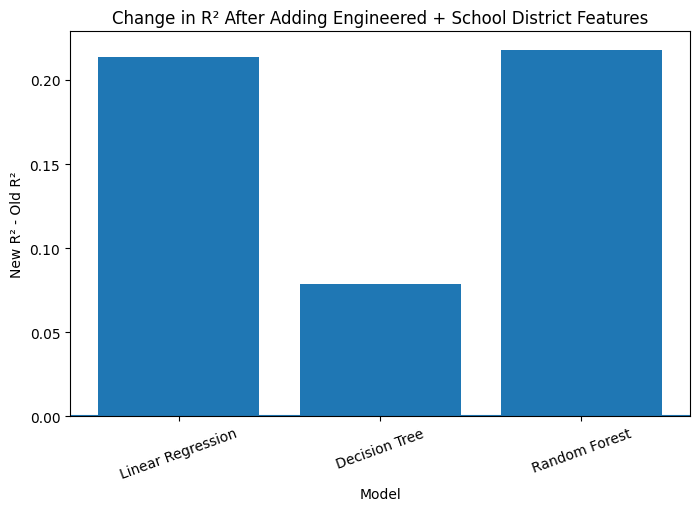

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(improvement_results["Model"], improvement_results["R2_Change"])

plt.axhline(0)
plt.title("Change in R² After Adding Engineered + School District Features")
plt.xlabel("Model")
plt.ylabel("New R² - Old R²")
plt.xticks(rotation=20)
plt.show()

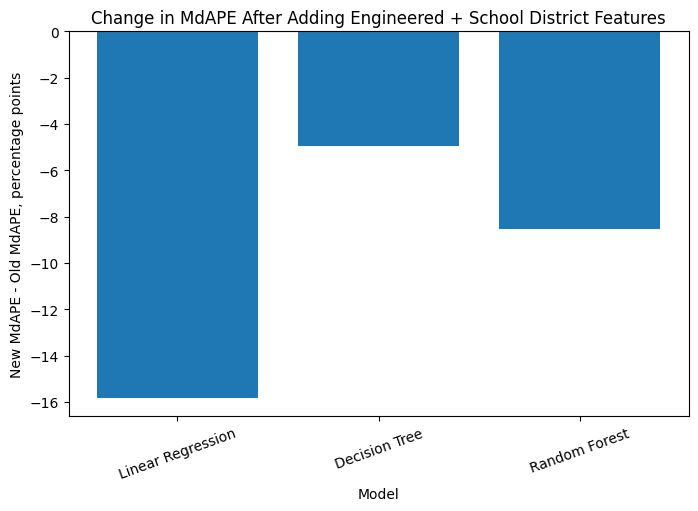

In [46]:
plt.figure(figsize=(8, 5))

plt.bar(improvement_results["Model"], improvement_results["MdAPE_%_Change"])

plt.axhline(0)
plt.title("Change in MdAPE After Adding Engineered + School District Features")
plt.xlabel("Model")
plt.ylabel("New MdAPE - Old MdAPE, percentage points")
plt.xticks(rotation=20)
plt.show()

In [47]:
best_old = comparison_results[
    comparison_results["Feature Set"] == "Old Features"
].sort_values("MdAPE").iloc[0]

best_new = comparison_results[
    comparison_results["Feature Set"] == "New Features + School District"
].sort_values("MdAPE").iloc[0]

print("Best old-feature model by MdAPE:")
print(best_old)

print("\nBest new-feature model by MdAPE:")
print(best_new)

Best old-feature model by MdAPE:
Feature Set     Old Features
Model          Random Forest
R2                  0.138849
MAPE                0.688787
MdAPE               0.334541
MAPE_%             68.878718
MdAPE_%            33.454053
Name: 2, dtype: object

Best new-feature model by MdAPE:
Feature Set    New Features + School District
Model                           Random Forest
R2                                   0.356843
MAPE                                 2.371295
MdAPE                                0.249375
MAPE_%                             237.129456
MdAPE_%                             24.937464
Name: 5, dtype: object


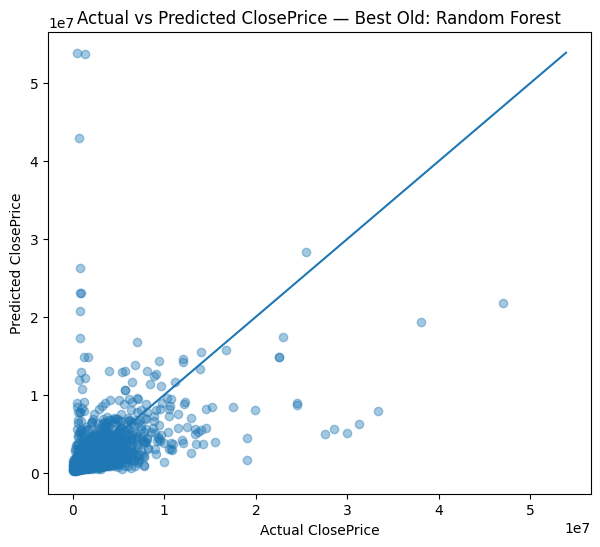

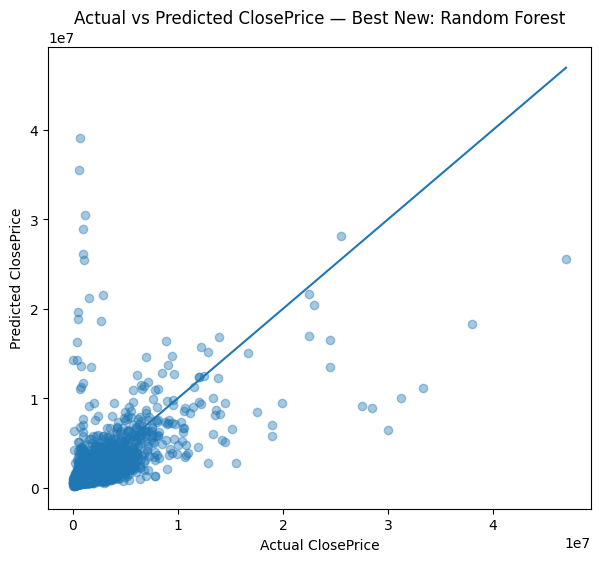

In [48]:
best_old_preds = all_predictions[(best_old["Feature Set"], best_old["Model"])]
best_new_preds = all_predictions[(best_new["Feature Set"], best_new["Model"])]

for label, preds in [
    (f"Best Old: {best_old['Model']}", best_old_preds),
    (f"Best New: {best_new['Model']}", best_new_preds)
]:
    plt.figure(figsize=(7, 6))
    plt.scatter(test_df["ClosePrice"], preds, alpha=0.4)
    
    min_price = min(test_df["ClosePrice"].min(), preds.min())
    max_price = max(test_df["ClosePrice"].max(), preds.max())
    
    plt.plot([min_price, max_price], [min_price, max_price])
    
    plt.title(f"Actual vs Predicted ClosePrice — {label}")
    plt.xlabel("Actual ClosePrice")
    plt.ylabel("Predicted ClosePrice")
    plt.show()

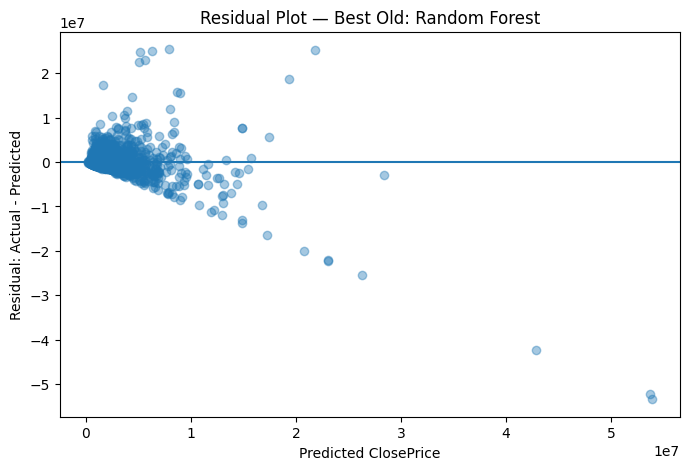

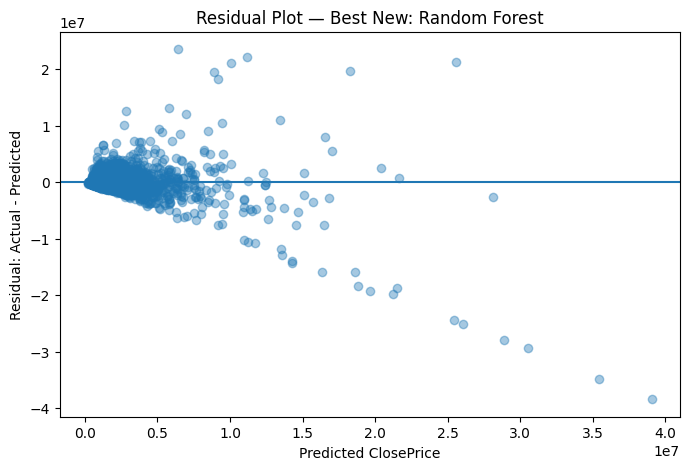

In [49]:
for label, preds in [
    (f"Best Old: {best_old['Model']}", best_old_preds),
    (f"Best New: {best_new['Model']}", best_new_preds)
]:
    residuals = test_df["ClosePrice"] - preds
    
    plt.figure(figsize=(8, 5))
    plt.scatter(preds, residuals, alpha=0.4)
    plt.axhline(0)
    
    plt.title(f"Residual Plot — {label}")
    plt.xlabel("Predicted ClosePrice")
    plt.ylabel("Residual: Actual - Predicted")
    plt.show()

In [50]:
price_bin_df = test_df[["ClosePrice"]].copy()

price_bin_df["PriceBin"] = pd.qcut(
    price_bin_df["ClosePrice"],
    q=5,
    labels=["Lowest", "Low-Mid", "Middle", "High-Mid", "Highest"]
)

price_bin_df["BestOld_APE"] = (
    np.abs(price_bin_df["ClosePrice"] - best_old_preds)
    / price_bin_df["ClosePrice"]
)

price_bin_df["BestNew_APE"] = (
    np.abs(price_bin_df["ClosePrice"] - best_new_preds)
    / price_bin_df["ClosePrice"]
)

price_bin_results = price_bin_df.groupby("PriceBin", observed=True).agg(
    median_close_price=("ClosePrice", "median"),
    best_old_mdape=("BestOld_APE", "median"),
    best_new_mdape=("BestNew_APE", "median"),
    count=("ClosePrice", "count")
).reset_index()

price_bin_results["best_old_mdape_%"] = price_bin_results["best_old_mdape"] * 100
price_bin_results["best_new_mdape_%"] = price_bin_results["best_new_mdape"] * 100
price_bin_results["mdape_change_%"] = (
    price_bin_results["best_new_mdape_%"] -
    price_bin_results["best_old_mdape_%"]
)

price_bin_results

,PriceBin,median_close_price,best_old_mdape,best_new_mdape,count,best_old_mdape_%,best_new_mdape_%,mdape_change_%
0,Lowest,449000.0,0.899705,0.553156,2617,89.970506,55.315586,-34.654920
1,Low-Mid,699000.0,0.339836,0.218882,2546,33.983610,21.888183,-12.095428
2,Middle,925000.0,0.168773,0.170546,2561,16.877274,17.054635,0.177361
3,High-Mid,1340000.0,0.227464,0.196384,2563,22.746353,19.638383,-3.107970
4,Highest,2398000.0,0.369288,0.273628,2571,36.928788,27.362806,-9.565983


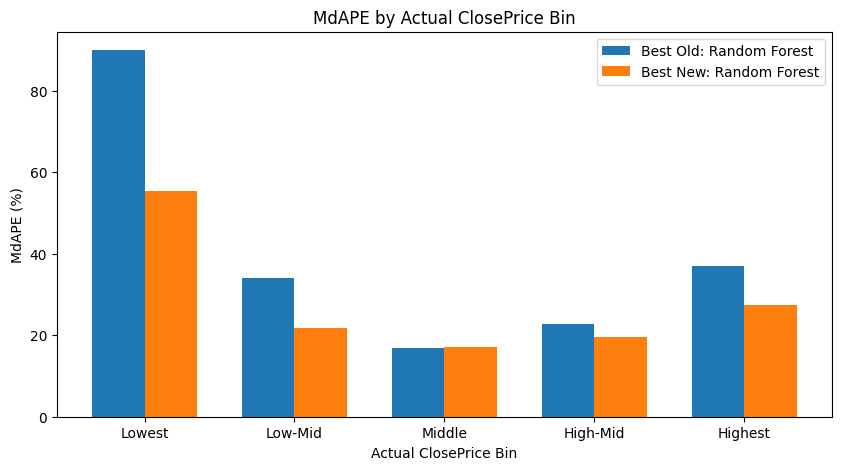

In [51]:
plt.figure(figsize=(10, 5))

x_bins = np.arange(len(price_bin_results["PriceBin"]))
width = 0.35

plt.bar(
    x_bins - width / 2,
    price_bin_results["best_old_mdape_%"],
    width,
    label=f"Best Old: {best_old['Model']}"
)

plt.bar(
    x_bins + width / 2,
    price_bin_results["best_new_mdape_%"],
    width,
    label=f"Best New: {best_new['Model']}"
)

plt.title("MdAPE by Actual ClosePrice Bin")
plt.xlabel("Actual ClosePrice Bin")
plt.ylabel("MdAPE (%)")
plt.xticks(x_bins, price_bin_results["PriceBin"])
plt.legend()
plt.show()

In [53]:
best_by_r2 = comparison_results.sort_values("R2", ascending=False).iloc[0]
best_by_mape = comparison_results.sort_values("MAPE", ascending=True).iloc[0]
best_by_mdape = comparison_results.sort_values("MdAPE", ascending=True).iloc[0]

print("Best model by R²:")
print(best_by_r2[["Feature Set", "Model", "R2", "MAPE_%", "MdAPE_%"]])

print("\nBest model by MAPE:")
print(best_by_mape[["Feature Set", "Model", "R2", "MAPE_%", "MdAPE_%"]])

print("\nBest model by MdAPE:")
print(best_by_mdape[["Feature Set", "Model", "R2", "MAPE_%", "MdAPE_%"]])

Best model by R²:
Feature Set    New Features + School District
Model                       Linear Regression
R2                                   0.505912
MAPE_%                              52.990336
MdAPE_%                             29.346557
Name: 3, dtype: object

Best model by MAPE:
Feature Set    New Features + School District
Model                       Linear Regression
R2                                   0.505912
MAPE_%                              52.990336
MdAPE_%                             29.346557
Name: 3, dtype: object

Best model by MdAPE:
Feature Set    New Features + School District
Model                           Random Forest
R2                                   0.356843
MAPE_%                             237.129456
MdAPE_%                             24.937464
Name: 5, dtype: object


In [54]:
# Diagnose unusually high MAPE for New Features + Random Forest

rf_new_preds = all_predictions[("New Features + School District", "Random Forest")]

rf_error_df = test_df.copy()
rf_error_df["PredictedClosePrice_RF_New"] = rf_new_preds
rf_error_df["AbsoluteError_RF_New"] = (
    rf_error_df["ClosePrice"] - rf_error_df["PredictedClosePrice_RF_New"]
).abs()
rf_error_df["APE_RF_New"] = (
    rf_error_df["AbsoluteError_RF_New"] / rf_error_df["ClosePrice"]
)

rf_error_summary = rf_error_df["APE_RF_New"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

rf_error_summary

count    1.285800e+04
mean     2.371295e+00
std      2.173666e+02
min      7.187759e-07
50%      2.493746e-01
75%      4.682763e-01
90%      8.429465e-01
95%      1.278807e+00
99%      3.020845e+00
max      2.464761e+04
Name: APE_RF_New, dtype: float64

In [55]:
# worst percentage-error cases

cols_to_show = [
    "CloseDate",
    "ClosePrice",
    "PredictedClosePrice_RF_New",
    "APE_RF_New",
    "LivingArea",
    "Bedrooms",
    "Bathrooms",
    "LotSize",
    "DistrictName",
    "HasUnifiedDistrict"
]

optional_cols = ["City", "PostalCode", "CountyOrParish", "YearBuilt", "PropertyAge"]

for col in optional_cols:
    if col in rf_error_df.columns and col not in cols_to_show:
        cols_to_show.append(col)

rf_error_df[cols_to_show].sort_values("APE_RF_New", ascending=False).head(20)

,CloseDate,ClosePrice,PredictedClosePrice_RF_New,APE_RF_New,LivingArea,Bedrooms,Bathrooms,LotSize,DistrictName,HasUnifiedDistrict,City,PostalCode,CountyOrParish,YearBuilt,PropertyAge
407119,2026-06-18,580.0,1.429620e+07,24647.613785,1910.0,2.0,2.0,6.970000e+03,Desert Sands Unified,1,Palm Desert,92211,Riverside,2001.0,25.0
410155,2026-06-25,12000.0,1.039020e+06,85.585012,2400.0,4.0,3.0,2.528222e+04,Unknown,0,Manchester,95459,Mendocino,1990.0,36.0
402960,2026-06-09,85000.0,6.357556e+06,73.794779,1730.0,4.0,2.0,3.049000e+03,Maricopa Unified,1,Maricopa,93252,Kern,1916.0,110.0
411094,2026-06-29,685000.0,3.907413e+07,56.042526,1161.0,2.0,1.0,3.920400e+03,Oceanside Unified,1,Oceanside,92057,San Diego,1976.0,50.0
404684,2026-06-12,635000.0,3.547774e+07,54.870463,1010.0,2.0,1.0,4.000000e+03,Oceanside Unified,1,Oceanside,92056,San Diego,1972.0,54.0
409369,2026-06-24,365000.0,1.631799e+07,43.706823,1015.0,1.0,1.0,4.000000e-02,Oceanside Unified,1,Oceanside,92057,San Diego,1970.0,56.0
399324,2026-06-01,450000.0,1.965767e+07,42.683710,2288.0,3.0,3.0,7.150000e+03,Rim of the World Unified,1,Running Springs,92382,San Bernardino,1978.0,48.0
411006,2026-06-29,487000.0,1.882268e+07,37.650269,1974.0,4.0,3.0,2.603000e+05,Unknown,0,Palmdale,93550,Los Angeles,2002.0,24.0
403629,2026-06-10,399000.0,1.428282e+07,34.796533,1910.0,4.0,2.0,6.534000e+03,Unknown,0,Bakersfield,93313,Kern,1996.0,30.0
407692,2026-06-19,1000000.0,2.886817e+07,27.868166,1976.0,2.0,2.0,1.163050e+05,Valley Center-Pauma Unified,1,Escondido,92026,San Diego,1976.0,50.0


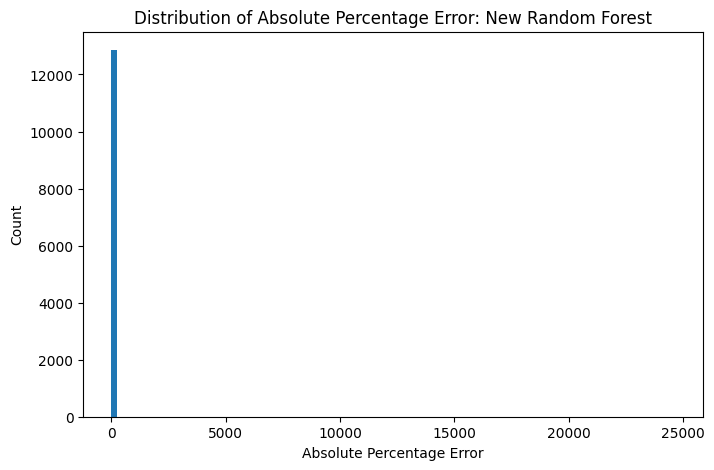

In [56]:
plt.figure(figsize=(8, 5))
plt.hist(rf_error_df["APE_RF_New"].dropna(), bins=100)
plt.title("Distribution of Absolute Percentage Error: New Random Forest")
plt.xlabel("Absolute Percentage Error")
plt.ylabel("Count")
plt.show()

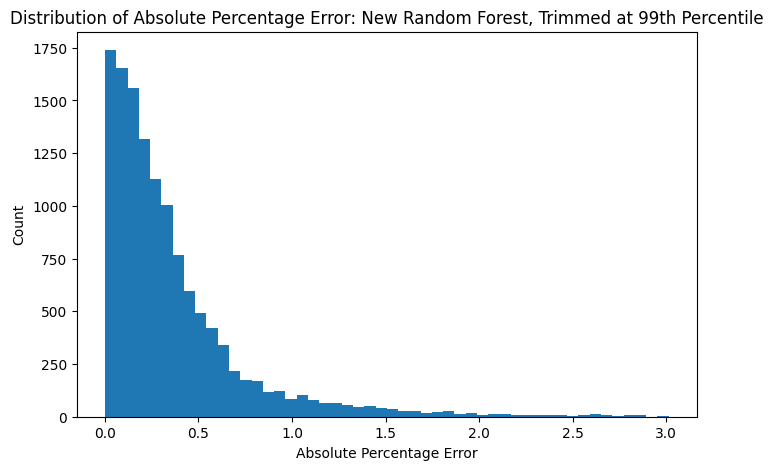

In [57]:
ape_upper = rf_error_df["APE_RF_New"].quantile(0.99)

plt.figure(figsize=(8, 5))
plt.hist(
    rf_error_df.loc[rf_error_df["APE_RF_New"] <= ape_upper, "APE_RF_New"].dropna(),
    bins=50
)
plt.title("Distribution of Absolute Percentage Error: New Random Forest, Trimmed at 99th Percentile")
plt.xlabel("Absolute Percentage Error")
plt.ylabel("Count")
plt.show()

## Old vs New Feature Set Comparison

I compared the original feature set against the expanded Week 6 feature set using the same standardized chronological train/test split. Since the June 2026 sold dataset is now available, June 2026 was used as the test month, and all prior months were used for training. The final split contained 399,155 training rows and 12,858 test rows.

The old feature set included the original property-level variables: `LivingArea`, `Bedrooms`, `Bathrooms`, `LotSize`, and missing-value indicator flags. The new feature set added engineered features such as bed/bath ratio, total rooms proxy, log-transformed living area, log-transformed lot size, property age where available, and school district information from the spatial join.

The school district feature was created by spatially joining property latitude and longitude against California unified school district boundaries. About 75% of properties matched to a unified school district, while about 25% were labeled as `Unknown`. I kept `Unknown` as its own category rather than dropping those rows, and I added `HasUnifiedDistrict` as an indicator for whether a property successfully matched to a unified district.

### Results Summary

The new feature set improved performance for every model by R² and MdAPE. This suggests that the engineered features and school district layer added useful predictive information beyond the original property-size variables.

The strongest overall model by R² was **Linear Regression with the new feature set**, with an R² of approximately 0.506. This was a large improvement over the old Linear Regression baseline, which had an R² of approximately 0.292. The new Linear Regression model also had the best MAPE at approximately 52.99% and a much lower MdAPE at approximately 29.35%.

The **Random Forest with the new feature set** achieved the best MdAPE at approximately 24.94%, meaning it made the best typical prediction by median percentage error. However, its MAPE was extremely high at approximately 237.13%, which suggests that it made a small number of very large percentage errors. Because MAPE is sensitive to extreme percentage errors, especially for lower-priced properties, this result should be interpreted carefully.

The Decision Tree also improved after adding the new features, with R² increasing from about 0.265 to 0.344 and MdAPE decreasing from about 37.06% to 32.09%. This suggests that tree-based models benefited from the expanded feature set, though the single Decision Tree was still weaker than the new Linear Regression model by R² and MAPE.

### Main Takeaway

The Week 6 feature engineering step was successful overall. Adding engineered property features and school district information substantially improved model performance compared with the old feature set. The most balanced model is currently **Linear Regression with the new feature set**, because it has the highest R² and lowest MAPE. The Random Forest is still promising because it has the lowest MdAPE, but its very high MAPE indicates instability on some test cases and should be investigated further before treating it as the best overall model.

Overall, these results show that the models were previously limited by missing location information. Adding a school district feature helped capture more regional price variation, which is especially important in real estate.